/tmp/ipykernel_1105/2483936652.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])
/tmp/ipykernel_1105/2483936652.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Loan_Status", y="TotalIncome", data=df, ax=axes[1], palette="magma")


--- Missing Values Cleared ---
 Gender               0
Married              0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Credit_History       0
Loan_Status          0
TotalIncome          0
dtype: int64


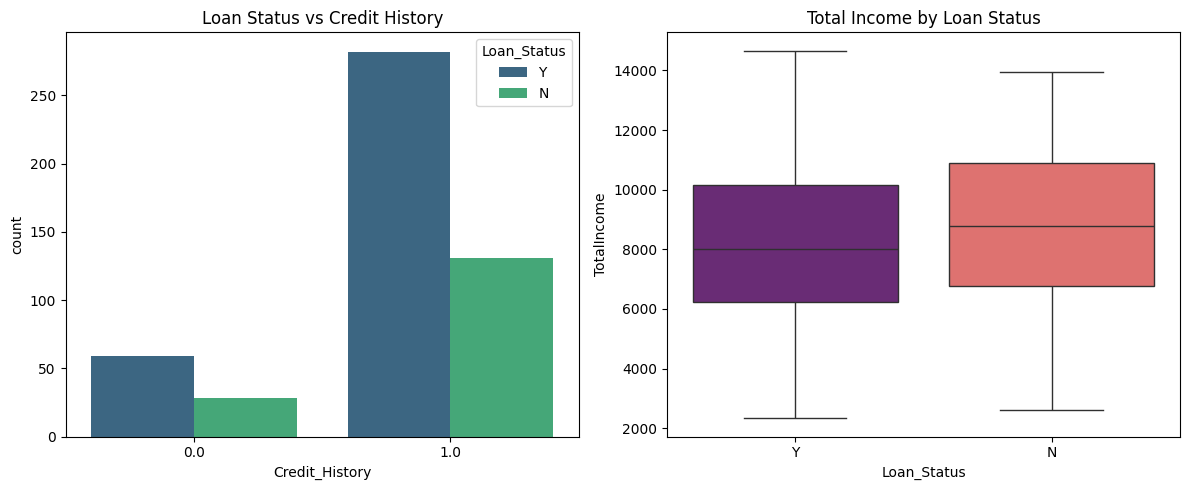


--- Model Performance Report ---
              precision    recall  f1-score   support

           0       0.31      0.28      0.29        29
           1       0.72      0.75      0.73        71

    accuracy                           0.61       100
   macro avg       0.51      0.51      0.51       100
weighted avg       0.60      0.61      0.60       100



In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# 1. GENERATE MOCK DATA (Simulating pd.read_csv('loan.csv'))
np.random.seed(42)
n = 500
df = pd.DataFrame(
    {
        "Gender": np.random.choice(["Male", "Female", None], size=n, p=[0.7, 0.25, 0.05]),
        "Married": np.random.choice(["Yes", "No", None], size=n, p=[0.6, 0.35, 0.05]),
        "ApplicantIncome": np.random.randint(2000, 10000, size=n),
        "CoapplicantIncome": np.random.randint(0, 5000, size=n),
        "LoanAmount": np.random.choice([np.nan, np.random.randint(50, 300)], size=n, p=[0.05, 0.95]),
        "Credit_History": np.random.choice([1.0, 0.0, None], size=n, p=[0.8, 0.15, 0.05]),
        "Loan_Status": np.random.choice(["Y", "N"], size=n, p=[0.7, 0.3]),
    }
)

# 2. DATA CLEANING & FEATURE ENGINEERING
for col in ["Gender", "Married", "Credit_History"]:
    df[col] = df[col].fillna(df[col].mode()[0])
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

print("--- Missing Values Cleared ---\n", df.isnull().sum())

# 3. QUICK EDA VISUALIZATIONS
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="Credit_History", hue="Loan_Status", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Loan Status vs Credit History")

sns.boxplot(x="Loan_Status", y="TotalIncome", data=df, ax=axes[1], palette="magma")
axes[1].set_title("Total Income by Loan Status")
plt.tight_layout()
plt.show()

# 4. PREPROCESSING & ENCODING
# Convert categorical strings directly to numeric categories
for col in ["Gender", "Married", "Loan_Status"]:
    df[col] = df[col].astype("category").cat.codes

X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. MODEL TRAINING & EVALUATION
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("\n--- Model Performance Report ---")
print(classification_report(y_test, model.predict(X_test)))

--- Step 1: Loading Dataset ---
Dataset Shape: (600, 6)

  neighbourhood_group        room_type price  minimum_nights  \
0           Manhattan  Entire home/apt   $56             1.0   
1               Bronx  Entire home/apt   $78             3.0   
2            Brooklyn  Entire home/apt   $82             3.0   

   number_of_reviews  review_rate_number  
0                 68                 1.0  
1                 47                 5.0  
2                 19                 3.0   

--- Step 2: Cleaning Data & Checking Missing Values ---
Missing values BEFORE cleaning:
neighbourhood_group    12
room_type               0
price                   0
minimum_nights         32
number_of_reviews       0
review_rate_number     27
dtype: int64 

Missing values AFTER cleaning:
neighbourhood_group    0
room_type              0
price                  0
minimum_nights         0
number_of_reviews      0
review_rate_number     0
dtype: int64 

--- Step 3: Rendering Visualizations ---


/tmp/ipykernel_1105/1838181055.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="room_type", y="price", data=df, ax=axes[1], palette="Pastel1")


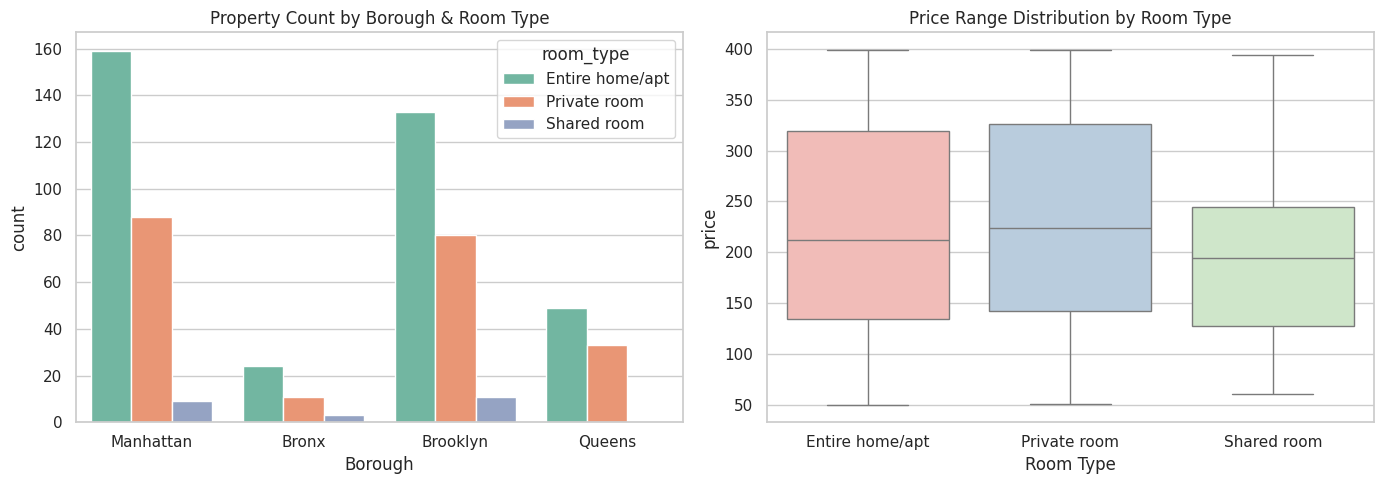

--- Step 4: Encoding Categorical Features ---
   neighbourhood_group  room_type  price  minimum_nights  number_of_reviews  \
0                    2          0   56.0             1.0                 68   
1                    0          0   78.0             3.0                 47   
2                    1          0   82.0             3.0                 19   

   review_rate_number  Is_Highly_Rated  
0                 1.0                0  
1                 5.0                1  
2                 3.0                0   

--- Step 5: Training Predictive Model ---

### Model Classification Performance Metrics ###
              precision    recall  f1-score   support

           0       0.13      0.06      0.08        33
           1       0.70      0.85      0.77        87

    accuracy                           0.63       120
   macro avg       0.42      0.46      0.43       120
weighted avg       0.55      0.63      0.58       120



In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Set up visual parameters
sns.set_theme(style="whitegrid")

# ==========================================
# 1. DATA LOADING & SIMULATION
# ==========================================
print("--- Step 1: Loading Dataset ---")
np.random.seed(42)
n = 600

# Generating data to mimic raw Airbnb Open Data
raw_data = {
    "neighbourhood_group": np.random.choice(
        ["Manhattan", "Brooklyn", "Queens", "Bronx", None], size=n, p=[0.4, 0.4, 0.13, 0.05, 0.02]
    ),
    "room_type": np.random.choice(
        ["Entire home/apt", "Private room", "Shared room"], size=n, p=[0.6, 0.35, 0.05]
    ),
    "price": [f"${np.random.randint(50, 400)}" for _ in range(n)],  # Raw currency strings
    "minimum_nights": np.random.choice([1, 2, 3, 30, np.nan], size=n, p=[0.4, 0.3, 0.2, 0.05, 0.05]),
    "number_of_reviews": np.random.randint(0, 150, size=n),
    "review_rate_number": np.random.choice([5.0, 4.0, 3.0, 2.0, 1.0, np.nan], size=n, p=[0.4, 0.3, 0.15, 0.05, 0.05, 0.05]),
}

df = pd.DataFrame(raw_data)
print(f"Dataset Shape: {df.shape}\n")
print(df.head(3), "\n")


# ==========================================
# 2. DATA CLEANING & ANALYSIS
# ==========================================
print("--- Step 2: Cleaning Data & Checking Missing Values ---")
print("Missing values BEFORE cleaning:")
print(df.isnull().sum(), "\n")

# A. Clean 'price' column (Strip '$' and convert to float)
df["price"] = df["price"].str.replace("$", "", regex=False).astype(float)

# B. Impute text missing values using the Mode
df["neighbourhood_group"] = df["neighbourhood_group"].fillna(df["neighbourhood_group"].mode()[0])
df["review_rate_number"] = df["review_rate_number"].fillna(df["review_rate_number"].mode()[0])

# C. Impute numerical missing values using the Median
df["minimum_nights"] = df["minimum_nights"].fillna(df["minimum_nights"].median())

print("Missing values AFTER cleaning:")
print(df.isnull().sum(), "\n")

# D. Feature Engineering (Creating binary classification target)
# 1 = Highly Rated (4-5 stars), 0 = Low/Average Rating (1-3 stars)
df["Is_Highly_Rated"] = (df["review_rate_number"] >= 4.0).astype(int)


# ==========================================
# 3. DATA VISUALIZATION (EDA)
# ==========================================
print("--- Step 3: Rendering Visualizations ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Listing count per region broken down by room type
sns.countplot(x="neighbourhood_group", hue="room_type", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Property Count by Borough & Room Type")
axes[0].set_xlabel("Borough")

# Plot 2: Price distribution per room type
sns.boxplot(x="room_type", y="price", data=df, ax=axes[1], palette="Pastel1")
axes[1].set_title("Price Range Distribution by Room Type")
axes[1].set_xlabel("Room Type")

plt.tight_layout()
plt.show()  # Pauses execution slightly until you close the visual window


# ==========================================
# 4. PREPROCESSING & DATA SPLITTING
# ==========================================
print("--- Step 4: Encoding Categorical Features ---")

# Convert strings to numeric classification codes
for col in ["neighbourhood_group", "room_type"]:
    df[col] = df[col].astype("category").cat.codes

print(df.head(3), "\n")

# Separate features (X) and target variable (y)
X = df.drop(columns=["review_rate_number", "Is_Highly_Rated"])
y = df["Is_Highly_Rated"]

# Train/Test Split (80% training, 20% validation evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ==========================================
# 5. MACHINE LEARNING MODEL & EVALUATION
# ==========================================
print("--- Step 5: Training Predictive Model ---")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Generate Predictions
predictions = model.predict(X_test)

print("\n### Model Classification Performance Metrics ###")
print(classification_report(y_test, predictions))